##  FMAToolbox tutorial

### Data representation

FMAT primarily handles two types of data (both 2d arrays): **Samples** and **Intervals**

- **Samples**: each row represents a sample of the form
  `[sample time, value1, value2, ...]`

- **Intervals**: each row represents an interval of the form
  `[onset time, offset time]`

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import pathlib

In [19]:
# define random samples and intervals
spikes = np.column_stack((np.random.randn(50)*20, np.random.randint(5,size=50))) # random spike times from 5 units, not time sorted
lfp = np.column_stack((np.linspace(0,20,100), np.random.randn(100))) # random lfp signal, sorted in time
intervals = np.linspace(5,15,18)
intervals = np.column_stack((intervals, intervals + np.random.rand(18))) # random overlapping intervals, sorted in time
print('spikes:'), print(spikes[:5]), print('lfp:'),  print(lfp[:5]), print('intervals:'), print(intervals[:10]);

spikes:
[[-31.11737816   3.        ]
 [ -1.60212456   1.        ]
 [  4.29859686   2.        ]
 [-26.27680993   1.        ]
 [ -6.72446765   4.        ]]
lfp:
[[ 0.          0.77487367]
 [ 0.2020202  -0.35633573]
 [ 0.4040404   0.8946045 ]
 [ 0.60606061  0.58891513]
 [ 0.80808081  0.49803664]]
intervals:
[[ 5.          5.04157218]
 [ 5.58823529  5.58828453]
 [ 6.17647059  6.32082659]
 [ 6.76470588  7.17670064]
 [ 7.35294118  7.4901579 ]
 [ 7.94117647  8.87051359]
 [ 8.52941176  9.51421678]
 [ 9.11764706  9.15680892]
 [ 9.70588235 10.45901885]
 [10.29411765 10.4007116 ]]


In [21]:
# remove overlaps in intervals
intervals = fma.intervals.consolidate(intervals)
print(intervals)

[[ 5.          5.04157218]
 [ 5.58823529  5.58828453]
 [ 6.17647059  6.32082659]
 [ 6.76470588  7.17670064]
 [ 7.35294118  7.4901579 ]
 [ 7.94117647  9.51421678]
 [ 9.70588235 10.45901885]
 [10.88235294 10.99434801]
 [11.47058824 11.92789365]
 [12.05882353 12.26158271]
 [12.64705882 13.73362699]
 [13.82352941 14.27614787]
 [14.41176471 14.62912816]
 [15.         15.26842386]]


In [22]:
# find spikes in intervals
fma.general.restrict(spikes,intervals)

array([[14.04917944,  0.        ],
       [ 7.39786145,  1.        ],
       [12.64861095,  0.        ]])

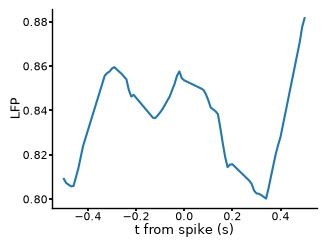

In [25]:
# PETH of LFP around spike times
_, t, peth = fma.analysis.PETH(lfp,spikes[:,0])

fig, ax = fma.plotting.makeFigure(size=(8,6))
ax[0].plot(t,peth)
ax[0].set(xlabel='t from spike (s)',ylabel='LFP');

Batch files contain a list of recording session's xml files and can be used to conveniently group sessions for an analysis

In [3]:
batch_file = pathlib.Path().cwd() / 'PhysioNet_example.batch'
session = fma.data.readBatchFile(batch_file)[0][3]
print(session)

/mnt/hubel-data-140/karadoc/Rat004_20240317/Rat004_20240317.xml


In [5]:
# load neuron spikes for the session, as well as relevant events
R = fma.regions.regions(session,states=['sws','rem'],events='ripples')

In [6]:
# get intervals for combinations of events
R.eventIntervals([['sleeps','sws'],['ripples']])

array([[ 1009.0224,  1009.0488],
       [ 1009.684 ,  1009.712 ],
       [ 1029.0856,  1029.1432],
       ...,
       [26938.6736, 26938.7224],
       [26943.2184, 26943.2472],
       [26944.2152, 26944.244 ]], shape=(3801, 2))

In [7]:
# get list of units (i.e., neurons) per region
R.units(regs=['pfc','nr'])

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117], dtype=uint8)

In [9]:
# get spikes per region
R.spikes(regs='pfc')

array([[1.99000000e-02, 1.12000000e+02],
       [3.59000000e-02, 1.02000000e+02],
       [8.74000000e-02, 1.16000000e+02],
       ...,
       [2.87695212e+04, 1.08000000e+02],
       [2.87695262e+04, 9.50000000e+01],
       [2.87695585e+04, 8.90000000e+01]], shape=(2833071, 2))

In [10]:
# get region population firing rates (rates of spikes per second), note how many functions support the argument 'when' to restrict their output
R.firingRate(regs=['nr','pfc'],when='rem')

array([[ 1126.025,   200.   ,    80.   ],
       [ 1126.075,   120.   ,   120.   ],
       [ 1126.125,   100.   ,   160.   ],
       ...,
       [26969.875,   160.   ,   200.   ],
       [26969.925,   140.   ,   180.   ],
       [26969.975,   120.   ,   120.   ]], shape=(21427, 3))

In [11]:
# firing rate per unit
R.unitFiringRate(regs=['pfc','nr'],when='rem')

array([[1.1260250e+03, 0.0000000e+00, 0.0000000e+00, ..., 2.0000000e+01,
        0.0000000e+00, 0.0000000e+00],
       [1.1260750e+03, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [1.1261250e+03, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       ...,
       [2.6969875e+04, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [2.6969925e+04, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [2.6969975e+04, 2.0000000e+01, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00]], shape=(21427, 119))

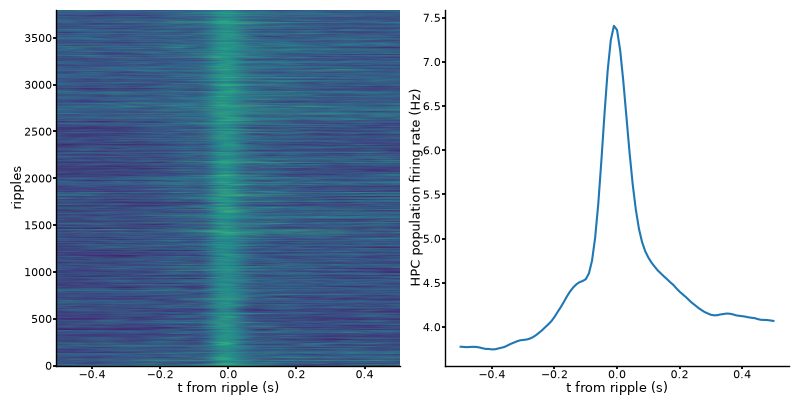

In [18]:
# HPC firing rate during ripples
ripple_peak = R.eventInfo('ripples','peak')
hpc_fr = R.firingRate(regs='hpc',norm=True)
mat, t, peth = fma.analysis.PETH(hpc_fr, ripple_peak)

fig, ax = fma.plotting.makeFigure(n=(1,2))
fma.plotting.plotColorMap(mat,x=t,ax=ax[0])
ax[0].set(xlabel='t from ripple (s)',ylabel='ripples')
ax[1].plot(t,peth)
ax[1].set(xlabel='t from ripple (s)',ylabel='HPC population firing rate (Hz)');

Exercise:
1. plot each neuron's response to ripples, dividing plots by region (use `spikes` combined with `PETH` to get the response curves, then `plorColorMap`)
2. verify if the average responce across neurons is the same as the population response of the region (last plot above this cell)
2. sort the rows of the colormpas first by peak amplitude, then by peak time, to see if neurons cluster in different types
3. try reproducing the plots by using only the first and last third of ripples, to spot differences across the recording time
4. devise a statistical test to find which neurons respond to ripples more than expected by chance

Hint: always read function docs (although they are sometimes incomplete...), always plot the variables you generate